# **A serie of statistical likelihood test for sed library improvement**

We are comparing two **non-nested models** of sed's photometry varying over less or more free parameters. To do so, we computed the likelihood value (Chi2) of N sources to both of these models, and use statistical tests --suitables to compare non-nested models-- to find which one is better. 

## **Initialisation**

In [1]:
### Libs ###
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from scipy.stats import norm
from lephare import statsplot as lsp

%matplotlib inline

LEPHAREDIR is being set to the default cache directory:
/home/hallouin/.cache/lephare/data
More than 1Gb may be written there.
LEPHAREWORK is being set to the default cache directory:
/home/hallouin/.cache/lephare/work
Default work cache is already linked. 
This is linked to the run directory:
/home/hallouin/.cache/lephare/runs/20251013T115331


In [2]:
### Load files ###
base_dir = os.path.abspath(os.path.join(os.getcwd(), '../..')) #change to your lephare base_dir

path_A = os.path.join(base_dir, 'training_stats/simulation_catalogs/star_gal/DC1_Buzzard_BT_LSST.out')
path_B = os.path.join(base_dir, 'training_stats/simulation_catalogs/star_gal/DC1_Buzzard_PICKLES_LSST.out')
tab_A = lsp.lephare_to_pandas(path_A)
tab_B = lsp.lephare_to_pandas(path_B)
tab_A = tab_A[tab_A['Z_BEST'] > 0]
tab_B = tab_B[tab_B['Z_BEST'] > 0]

In [3]:
def join_tables(base_df, tables, how="outer", ignore=None, put_match_first=True, drop_unmatched=True, indicator=False):
    # Normalize single join instruction to list
    if isinstance(tables, tuple) and len(tables) == 3:
        tables = [tables]

    result = base_df.copy()
    match_columns = []

    for other_df, base_col, other_col in tables:
        result = result.merge(
            other_df,
            how=how,
            left_on=base_col,
            right_on=other_col,
            indicator=indicator
        )
        match_columns.append(base_col)
    # Drop unmatched rows (forces inner join behavior)
    if drop_unmatched:
        for col in match_columns:
            result = result[result[col].notna()]
    
    if indicator:
        result = result[(result['_merge'] == 'left_only') | (result['_merge'] == 'both')]
        result["present"] = (result['_merge'] == "both").astype(int)
        result = result.drop(columns=["_merge"])
    # Drop ignored columns
    if ignore:
        result = result.drop(columns=[c for c in ignore if c in result.columns])

    # Move match columns to front
    if put_match_first:
        # Keep order if multiple match columns
        front_cols = [c for c in match_columns if c in result.columns]
        other_cols = [c for c in result.columns if c not in front_cols]
        result = result[front_cols + other_cols]

    return result


In [4]:
### Initialize parameters and Chi2 list ###
kA = 3 # Unknow, Z, alpha (normalisation)
kB = 4 # Teff, logg, FeH, alpha (normalisation)
ndata = 6   # ugrizy

In [5]:
def AIC_list(chi2_min, k):
    chi2_min = np.asarray(chi2_min)
    AIC = chi2_min + 2 * k
    return AIC

def BIC_list(chi2_min, n, k):
    chi2_min = np.asarray(chi2_min)

    if np.isscalar(n):
        n = np.full_like(chi2_min, n, dtype=float)
    else:
        n = np.asarray(n)
        if len(n) != len(chi2_min):
            raise ValueError("n must be scalar or same length as chi2_min")

    BIC = chi2_min + k*np.log(n)
    return BIC

In [10]:
error_mask = tab_A['ERR_MAG_OBS1']<100
AIC_gal = AIC_list(tab_A[error_mask]['CHI_BEST'], kA)
AIC_star = AIC_list(tab_A[error_mask]['CHI_STAR'], kB)

BIC_gal = BIC_list(tab_A[error_mask]['CHI_BEST'], 6, kA)
BIC_star = BIC_list(tab_A[error_mask]['CHI_STAR'], 6, kB)

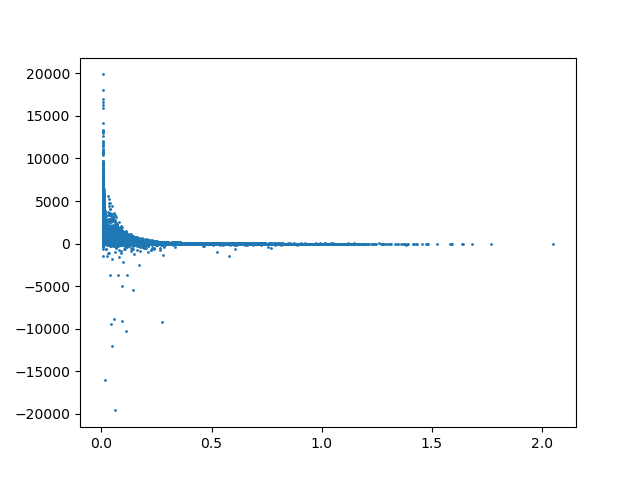

In [11]:
%matplotlib widget
plt.figure()
plt.scatter(tab_A[error_mask]['ERR_MAG_OBS1'], AIC_star-AIC_gal, s=1)
# plt.hist(AIC_star-AIC_gal, bins=np.linspace(-50,50,1000))
plt.show()

## **Full lib use ?**

In [3]:
def evidence_from_chi2_grid(chi2_grid, template_weights=None, subtract_min=True):
    """
    Estimate marginal likelihood (evidence) for each source from a grid of chi2.

    Parameters
    ----------
    chi2_grid : array-like, shape (N_sources, N_templates)
        Per-source chi2 for every template in a model family.
    template_weights : None or array-like, shape (N_templates,)
        Prior weight for each template. If None, uniform weights are used.
        Weights need not sum to 1; function will account for normalization.
    subtract_min : bool
        If True, compute log-sum-exp using min subtraction for numerical stability.

    Returns
    -------
    logZ : array, shape (N_sources,)
        log evidence estimate for each source (natural log, up to an additive constant
        that is the same across models if you use same conventions).
    """
    chi2 = np.asarray(chi2_grid, dtype=float)
    Nsrc, Nt = chi2.shape

    if template_weights is None:
        logw = np.log(np.ones(Nt) / Nt)   # uniform in probability space
    else:
        w = np.asarray(template_weights, dtype=float)
        if w.shape != (Nt,):
            raise ValueError("template_weights must be length N_templates")
        # normalize to sum=1 and take log
        w = w / np.sum(w)
        logw = np.log(w)

    # log-likelihood per template: ln L = -0.5 * chi2  (plus constant)
    logL = -0.5 * chi2   # shape (Nsrc, Nt)

    # Combine template prior and log-likelihood: log [ w_t * L_t ]
    logwtL = logw[None, :] + logL  # broadcasting

    # log-sum-exp over templates -> log evidence (up to additive constant)
    # to avoid huge/small numbers we use scipy.special.logsumexp
    logZ = logsumexp(logwtL, axis=1)  # shape (Nsrc,)

    # Optionally subtract the same constant across models for numeric comparability,
    # but usually you want raw logZ to compare between models. Return as-is.
    return logZ



def model_posteriors(logZ_dict, model_priors=None):
    """
    Compute posterior probabilities P(M|D) for multiple model families, per source.

    Parameters
    ----------
    logZ_dict : dict
        Keys are model names (strings). Values are arrays of log evidence, shape (N_sources,).
        All arrays must have same shape and order of sources.
    model_priors : None or dict
        Prior probability for each model name. If None, uniform priors over models are used.

    Returns
    -------
    posteriors : dict
        For each model name returns array of posterior probs (N_sources,)
    """
    model_names = list(logZ_dict.keys())
    logZs = np.vstack([logZ_dict[m] for m in model_names])  # shape (n_models, Nsrc)

    N_models, Nsrc = logZs.shape

    if model_priors is None:
        log_priors = np.log(np.ones(N_models) / N_models)
    else:
        pri = np.array([model_priors.get(m, 0.0) for m in model_names], dtype=float)
        if np.any(pri < 0):
            raise ValueError("model priors must be non-negative")
        if pri.sum() == 0:
            raise ValueError("at least one prior must be positive")
        pri = pri / pri.sum()
        log_priors = np.log(pri)

    # For each source: compute log P(M) + logZ, then normalize
    # log numerator shape (n_models, Nsrc)
    log_num = log_priors[:, None] + logZs

    # normalize across models: log evidence sum = logsumexp(log_num)
    log_denom = logsumexp(log_num, axis=0)  # shape (Nsrc,)
    log_post = log_num - log_denom[None, :]  # shape (n_models, Nsrc)

    post = np.exp(log_post)  # shape (n_models, Nsrc)

    # return as dict of arrays
    return {m: post[i, :] for i, m in enumerate(model_names)}


In [ ]:
# suppose chi2_star is (Nsrc, Nstar_templates), chi2_gal is (Nsrc, Ngal_templates)
logZ_star = evidence_from_chi2_grid(chi2_star, template_weights=None)
logZ_gal  = evidence_from_chi2_grid(chi2_gal,  template_weights=None)

logZ = {'star': logZ_star, 'gal': logZ_gal}
priors = {'star': 0.5, 'gal': 0.5}   # pick sensible prior or make sky/magnitude-dependent

post = model_posteriors(logZ, model_priors=priors)
p_star = post['star']   # array length Nsrc of posterior P(star|data)
p_gal  = post['gal']    # should be 1-p_star if only 2 models

# Classification threshold example:
is_star = p_star > 0.9   # conservative star classification
